In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/gpu_ml_ready.csv")

df.shape

(1165, 17)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   manufacturer            1165 non-null   int64  
 1   releaseyear             1165 non-null   float64
 2   memsize                 1165 non-null   float64
 3   gpuclock                1165 non-null   int64  
 4   memclock                1165 non-null   float64
 5   unifiedshader           1165 non-null   float64
 6   tmu                     1165 non-null   int64  
 7   rop                     1165 non-null   int64  
 8   g3dmark                 1165 non-null   int64  
 9   g2dmark                 1165 non-null   int64  
 10  tdp                     1165 non-null   float64
 11  powerperformance        1165 non-null   float64
 12  performance_per_watt    1165 non-null   float64
 13  performance_per_gb      1165 non-null   float64
 14  performance_per_shader  1165 non-null   float64
 15

In [41]:
df.isnull().sum().sum()

np.int64(0)

In [47]:
X_reg = df.drop(
    columns=[
        "g3dmark",
        "performance_category"
    ]
)

y_reg = df["g3dmark"]

print(X_reg.shape)

(1165, 15)


In [48]:
print(
    X_reg.select_dtypes(include="object").columns
)

Index([], dtype='str')


In [46]:
corr_target = (
    df.corr(numeric_only=True)["g3dmark"]
    .sort_values(ascending=False)
)

print(corr_target)

g3dmark                   1.000000
memsize                   0.816868
g2dmark                   0.787120
powerperformance          0.715753
performance_per_watt      0.715747
tdp                       0.669878
tmu                       0.630840
releaseyear               0.612902
rop                       0.607258
unifiedshader             0.595098
performance_per_gb        0.532869
memclock                  0.416678
gpuclock                  0.398736
performance_per_shader    0.155287
manufacturer             -0.090600
gpu_age                  -0.612902
performance_category     -0.614313
Name: g3dmark, dtype: float64


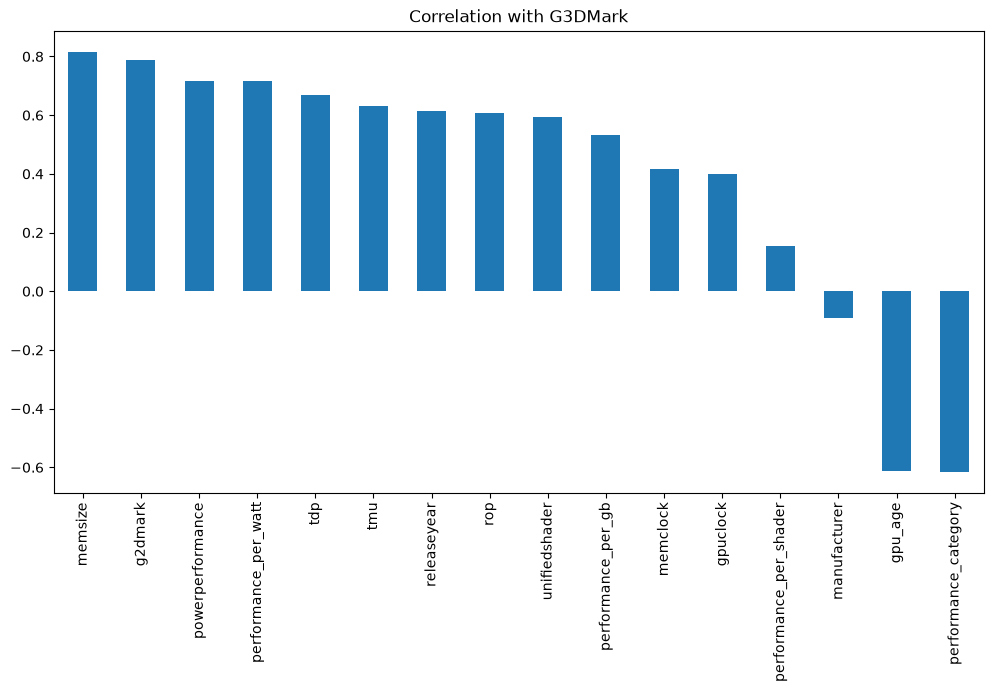

In [49]:
import matplotlib.pyplot as plt

corr_target.drop("g3dmark").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Correlation with G3DMark")
plt.show()

In [51]:
corr_matrix = X_reg.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

In [52]:
high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print(high_corr)

['performance_per_watt', 'gpu_age']


In [53]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(
    X_reg,
    y_reg,
    random_state=42
)

In [54]:
mi_df = pd.DataFrame({
    "Feature": X_reg.columns,
    "MI Score": mi_scores
})

In [55]:
mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
)

print(mi_df.head(10))

                   Feature  MI Score
13  performance_per_shader  1.995034
12      performance_per_gb  1.453613
2                  memsize  0.987953
5            unifiedshader  0.966931
1              releaseyear  0.944381
14                 gpu_age  0.942209
8                  g2dmark  0.818239
6                      tmu  0.559719
11    performance_per_watt  0.546552
10        powerperformance  0.535240


In [56]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_reg,
    y_train_reg
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [58]:
importance_df = pd.DataFrame({
    "Feature": X_train_reg.columns,
    "Importance": rf.feature_importances_
})

In [59]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                   Feature  Importance
2                  memsize    0.486597
8                  g2dmark    0.321463
12      performance_per_gb    0.080535
9                      tdp    0.045298
10        powerperformance    0.015178
13  performance_per_shader    0.014035
11    performance_per_watt    0.012239
1              releaseyear    0.006222
5            unifiedshader    0.005856
14                 gpu_age    0.004771


In [60]:
from sklearn.feature_selection import RFE

In [61]:
rfe = RFE(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    n_features_to_select=10
)

In [62]:
rfe.fit(
    X_train_reg,
    y_train_reg
)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestR...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestRegressor,RandomForestR...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['manufacturer','releaseyear','memsize',...,'performance_per_gb', 'performance_per_shader','gpu_age']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(10)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,15
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](15,)","[4,1,1,...,1,1,1]"


In [63]:
selected_features = (
    X_train_reg.columns[rfe.support_]
)

print(selected_features)

Index(['releaseyear', 'memsize', 'unifiedshader', 'g2dmark', 'tdp',
       'powerperformance', 'performance_per_watt', 'performance_per_gb',
       'performance_per_shader', 'gpu_age'],
      dtype='str')


Top Correlated Features:

['performance_per_watt', 'gpu_age']

Top Mutual Information Features:

                   Feature  MI Score
13  performance_per_shader  1.995034
12      performance_per_gb  1.453613
2                  memsize  0.987953
5            unifiedshader  0.966931
1              releaseyear  0.944381
14                 gpu_age  0.942209
8                  g2dmark  0.818239
6                      tmu  0.559719
11    performance_per_watt  0.546552
10        powerperformance  0.535240

Top Random Forest Features:

                   Feature  Importance
2                  memsize    0.486597
8                  g2dmark    0.321463
12      performance_per_gb    0.080535
9                      tdp    0.045298
10        powerperformance    0.015178
13  performance_per_shader    0.014035
11    performance_per_watt    0.012239
1              releaseyear    0.006222
5            unifiedshader    0.005856
14                 gpu_age    0.004771

RFE Selected Features:

Index(['releaseyear', 'memsize', 'unifiedshader', 'g2dmark', 'tdp',
       'powerperformance', 'performance_per_watt', 'performance_per_gb',
       'performance_per_shader', 'gpu_age'],
      dtype='str')

In [65]:
selected_features = [
    'releaseyear',
    'memsize',
    'unifiedshader',
    'g2dmark',
    'tdp',
    'powerperformance',
    'performance_per_watt',
    'performance_per_gb',
    'performance_per_shader',
    'gpu_age'
]

X_reg_selected = X_reg[selected_features]